<a href="https://colab.research.google.com/github/thevishali/data_visualization/blob/main/dvt_exp3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, LabelEncoder

In [3]:
from google.colab import files

uploaded = files.upload()

Saving vehicle_market.csv to vehicle_market.csv


In [6]:
import os

print(os.listdir())


['.config', 'vehicle_market.csv', 'sample_data']


In [9]:
import pandas as pd

df = pd.read_csv("vehicle_market.csv")

df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [10]:
print(df.shape)

df.info()

(4340, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB


In [11]:
print("Missing Values\n")
print(df.isnull().sum())

Missing Values

name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64


In [12]:
numeric_cols = df.select_dtypes(include=np.number).columns

df[numeric_cols] = df[numeric_cols].fillna(
    df[numeric_cols].median()
)

categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print(df.isnull().sum())

name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64


In [13]:
print("Duplicate Rows :", df.duplicated().sum())

df.drop_duplicates(inplace=True)

print("After Removal :", df.shape)

Duplicate Rows : 763
After Removal : (3577, 8)


In [14]:
Q1 = df["selling_price"].quantile(0.25)

Q3 = df["selling_price"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR

upper = Q3 + 1.5 * IQR

outliers = df[
    (df["selling_price"] < lower) |
    (df["selling_price"] > upper)
]

print(outliers.head())

                                              name  year  selling_price  \
12                 Toyota Corolla Altis 1.8 VL CVT  2018        1650000   
29                      Jaguar XF 2.2 Litre Luxury  2014        1964999   
30            Mercedes-Benz New C-Class 220 CDI AT  2013        1425000   
35                 Audi A6 2.0 TDI  Design Edition  2013        1735000   
36  Mercedes-Benz New C-Class C 220 CDI Avantgarde  2012        1375000   

    km_driven    fuel seller_type transmission         owner  
12      25000  Petrol      Dealer    Automatic   First Owner  
29      28000  Diesel      Dealer    Automatic   First Owner  
30      59000  Diesel      Dealer    Automatic   First Owner  
35      50000  Diesel      Dealer    Automatic   First Owner  
36      33800  Diesel      Dealer    Automatic  Second Owner  


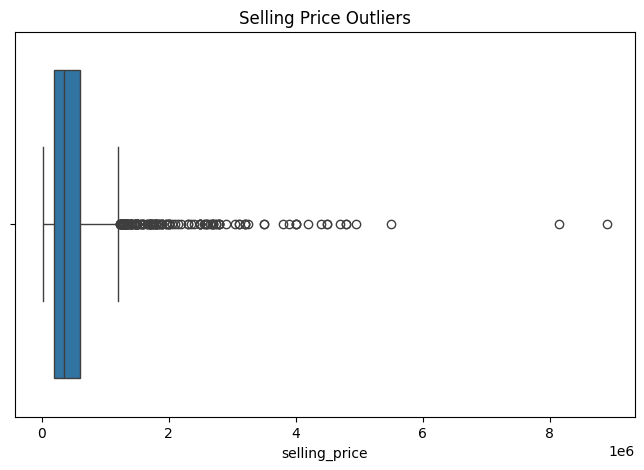

In [15]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["selling_price"])

plt.title("Selling Price Outliers")

plt.show()

In [16]:
scaler = MinMaxScaler()

df[["selling_price"]] = scaler.fit_transform(
    df[["selling_price"]]
)

print(df[["selling_price"]].head())

   selling_price
0       0.004505
1       0.012950
2       0.065315
3       0.025901
4       0.048423


In [17]:
encoder = LabelEncoder()

df["fuel"] = encoder.fit_transform(df["fuel"])

df["seller_type"] = encoder.fit_transform(df["seller_type"])

df["transmission"] = encoder.fit_transform(df["transmission"])

df["owner"] = encoder.fit_transform(df["owner"])

print(df[["fuel", "seller_type", "transmission", "owner"]].head())

   fuel  seller_type  transmission  owner
0     4            1             1      0
1     4            1             1      0
2     1            1             1      0
3     4            1             1      0
4     1            1             1      2


In [18]:
name_encoder = LabelEncoder()

df["name"] = name_encoder.fit_transform(
    df["name"].astype(str)
)

print(df[["name"]].head())

   name
0   775
1  1041
2   505
3   118
4   279


In [19]:
df.to_csv("cleaned_vehicle_market.csv", index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.
